# ASSIGNMENT 1 Q2

# ASSIGNMENT 1 Q2

In [58]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

df = pd.read_csv("silver.csv")
train_size = int(len(df) * 0.7)
tscv = TimeSeriesSplit(n_splits=10)


## Garch models

In [59]:
return_rate = 100*df["target_return"].dropna()
train = return_rate.iloc[:train_size]
test = return_rate.iloc[train_size:]

In [60]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import itertools

p-value: 2.0788240587285072e-28
      lb_stat  lb_pvalue
5    8.606960   0.125806
10  17.629830   0.061538
15  21.621742   0.118113


<Figure size 1200x600 with 0 Axes>

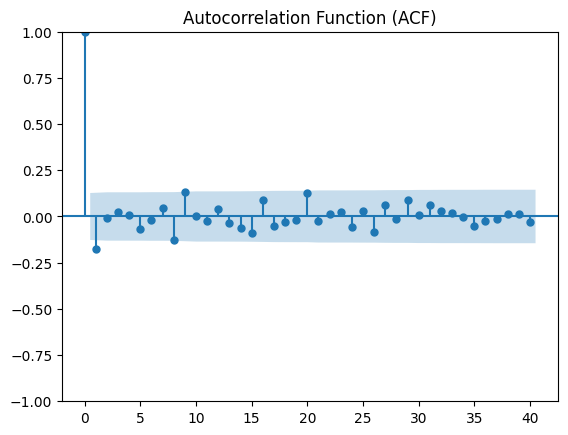

<Figure size 1200x600 with 0 Axes>

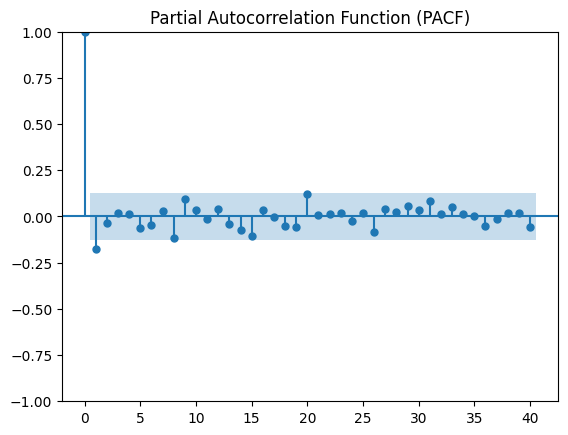

In [61]:
# Perform Augmented Dickey-Fuller test
result = adfuller(train)
print("p-value:", result[1])
# The timeseries appears to be stationary based on the ADF test. We can proceed with modeling the returns.

ljung_box_result = acorr_ljungbox(return_rate, lags=[5, 10, 15], return_df=True)
print(ljung_box_result)
# Not white noise, fit ARMA to the returns.

# Plot ACF
plt.figure(figsize=(12,6))
plot_acf(return_rate, lags=40)   # up to 40 lags
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plt.figure(figsize=(12,6))
plot_pacf(return_rate, lags=40, method="ywm")  # Yule-Walker method
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:
def fit_arma_garch(history,mod_spec,ahead=1):

    meanModel = ARIMA(history, order=mod_spec[0]).fit()
    meanResiduals = meanModel.resid
   
    ljung_box = acorr_ljungbox(meanResiduals, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None

    mean_fct=meanModel.forecast(steps=ahead) 

    volModel = arch_model(meanResiduals, mean="Zero", vol="GARCH", p=mod_spec[1], o=0, q=mod_spec[2], dist=mod_spec[3]).fit(disp="off")
        
    # Test model adequacy 
    residuals = volModel.resid
    cond_vol = volModel.conditional_volatility
    std_resid = residuals / cond_vol
    std_resid2 = std_resid**2

    ljung_box = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None

    ljung_box = acorr_ljungbox(std_resid2, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None
     
    vol_fct=volModel.forecast(horizon=ahead,reindex=False)

    return mean_fct, vol_fct.variance.values[-1]

In [ ]:

lags = [(0,0,0),(1,0,0),(0,0,1),(2,0,0),(0,0,2),(1,0,1),(2,0,1),(1,0,2)]
p_vals = range(1,4)
q_vals = range(1,4)
dists = ["normal", "t","skewt"]
candidate_models = list(itertools.product(lags, p_vals, q_vals, dists))

cv_results = []

for spec in candidate_models:
    mean_fold_errors = []
    var_fold_errors = []

    for train_idx, val_index in tscv.split(train):
        cv_train = train.iloc[train_idx]
        cv_valid = train.iloc[val_index]

        if len(cv_valid) == 0:
            continue

        pred_mean, pred_var = fit_arma_garch(cv_train, spec,len(cv_valid))
        if pred_mean is None or pred_var is None:
            continue
 
        # Realized variance proxy
        realized_var = (cv_valid.values**2)  
        var_fold_errors.append(mean_squared_error(realized_var,pred_var))
        mean_fold_errors.append(mean_squared_error(cv_valid.values, pred_mean))
            
    cv_results.append({
        "model": spec,
        "mean_cv_mse": np.mean(mean_fold_errors),
        "var_cv_mse": np.mean(var_fold_errors)
        })    

    print(f"Average CV MSE = {np.mean([r['mean_cv_mse'] for r in cv_results]):.6f}, {np.mean([r['var_cv_mse'] for r in cv_results]):.6f}")


InvalidParameterError: The 'y_pred' parameter of mean_squared_error must be an array-like. Got np.float64(1.8483790798037016) instead.

In [56]:
#Find best model in regards to mean forecast performance 
best_mean_result = min(cv_results, key=lambda x: x["mean_cv_mse"])
best_mean_spec = best_mean_result["model"]
print("\nBest model for mean forecast:")
print(best_mean_spec)

best_fit = fit_arma_garch(train,best_mean_spec)

predicted_mean = []
realized_mean = []

history = train.copy(deep=True)

for t in range(len(test)):
    fitted = fit_arma_garch(history, best_mean_spec, test=False).fit(disp="off")
    forecast = fitted.forecast(horizon=1,reindex=False)
    predicted_mean.append(forecast.mean.values[-1,0])

    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])

mean_test_mse = mean_squared_error(test.values,predicted_mean)

print("\nTest Set Performance for mean forecast")
print(f"Test MSE  : {mean_test_mse:.6f}")



Best model for mean forecast:
((0, 0, 0), 1, 1, 'normal')


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [43]:
#Find best model in regards to volatility forecast performance 
best_var_result = min(cv_results, key=lambda x: x["var_cv_mse"])
best_var_spec = best_var_result["model"]

predicted_var = []
realized_var = []

history = train.copy(deep=True)

for t in range(len(test)):
    fitted = fit_arma_garch(history, best_mean_spec, test=False).fit(disp="off")
    forecast = fitted.forecast(horizon=1,reindex=False)
    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])

    if forecast is None:
        predicted_var.append(predicted_var[-1] if predicted_var else 0)
        continue

    predicted_var.append(forecast.variance.values[-1,0])

# Realized variance proxy
var_test_mse = mean_squared_error(test.values**2,predicted_var)

print("\nTest Set Performance for volatility forecast")
print(f"Test MSE  : {var_test_mse:.6f}")



Test Set Performance for volatility forecast
Test MSE  : 261.500000


## XGBoost

In [51]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

train = df.iloc[:train_size]
test = df.iloc[train_size:]


param_grid = {
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[200,500,1000],
    "subsample":[0.8, 1.0],
    "colsample_bytree":[0.8, 1.0]
}


### Log return prediction

In [52]:

mean_features = [
    *[f"return_lag_{i}" for i in range(1,5)],
    "momentum_7",
    "momentum_14",
    "MA_ratio_short",
    "sp500_returns",
    "gold_returns",
    "brent_returns",
    "dxy_returns",
    "fx_returns",
    "vix_changes",
    "gold_silver_ratio",
    "gold_fx_interaction",
    "US_Interest_Rate",
    "US_10Y_Yield"    
]

X_train = train[mean_features]
y_train = train["target_return"]

grid_return = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror",random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_return.fit(X_train, y_train)
best_return_model = (grid_return.best_estimator_)

print(grid_return.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [53]:
vol_features = [
    "volatility_7",
    "volatility_14",
    "volatility_ratio",
    "realized_vol_21",
    "realized_vol_63",
    "gold_vol_21",
    "sp500_vol_21",
    "fx_vol_21",
    "brent_vol_21",
    "gold_returns",
    "fx_returns",
    "vix_changes",
    "VIX",
    "US_10Y_Yield", 
    *[f"abs_return_lag_{i}" for i in range(1,5)] 
]

X_train = train[vol_features]
y_train_vol = train["target_vol"]

grid_vol = GridSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),

    param_grid=param_grid,

    cv=tscv,

    scoring="neg_mean_squared_error",

    n_jobs=-1
)

grid_vol.fit(
    X_train,
    y_train_vol
)

best_vol_model = (
    grid_vol.best_estimator_
)

print(grid_vol.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [54]:
from sklearn.metrics import mean_squared_error

X_test = test[mean_features]

y_test = test["target_return"]

pred_return = (
    best_return_model.predict(X_test)
)

rmse_return = np.sqrt(
    mean_squared_error(
        y_test,
        pred_return
    )
)

print("Return RMSE")
print(rmse_return)

Return RMSE
0.03732509224599532


In [55]:
X_test = test[vol_features]
y_test_vol = test["target_vol"]

pred_vol = (
    best_vol_model.predict(X_test)
)

rmse_vol = np.sqrt(
    mean_squared_error(
        y_test_vol,
        pred_vol
    )
)

print("Volatility RMSE")
print(rmse_vol)

Volatility RMSE
0.004575156887360217
